# 06 · Interpretabilidad temporal de los modelos lineales

Este notebook identifica qué variables contribuyen más a las predicciones lineales y comprueba si su importancia es estable entre ventanas temporales y competiciones. Se comparan los coeficientes de Lasso y ElasticNet, mientras que la permutación se aplica a ElasticNet como referencia explicativa principal.

Se utilizan dos métodos complementarios. Los coeficientes estandarizados muestran dirección y magnitud condicional dentro del modelo, mientras que la permutation importance mide cuánto empeora el MAE del test futuro al desordenar una variable.

Ningún resultado de este notebook demuestra causalidad. Las variables rolling están correlacionadas y también reflejan rol, volumen de juego y decisiones del entrenador.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir() and (candidate / "reports").is_dir():
            return candidate
    raise FileNotFoundError("No se encontró el raíz del proyecto (data/raw y reports).")

ROOT = find_project_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")
print({"root": str(ROOT), "python": sys.version.split()[0], "pandas": pd.__version__, "platform": platform.platform()})

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED, PERMUTATION_REPEATS = 42, 5
TABLE_DIR = ROOT / "reports" / "tables" / "06_interpretability"
FIGURE_DIR = ROOT / "reports" / "figures" / "06_interpretability"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

dataset = pd.read_csv(PROCESSED_DIR / "player_pregame_target_game_3_5_1718.csv", parse_dates=["target_date"])
schedule = pd.read_csv(ROOT / "reports" / "tables" / "03_ml_benchmark" / "fold_schedule.csv", parse_dates=["train_end", "test_start", "test_end"])
assert len(dataset) == 7_269 and len(schedule) == 5

{'root': 'C:\\Users\\pablo\\OneDrive\\Documentos\\TFM\\tfm-scouting-ml-dl', 'python': '3.12.4', 'pandas': '2.2.2', 'platform': 'Windows-10-10.0.19045-SP0'}


## Registro y modelo interpretado

Se reconstruyen exactamente Lasso y ElasticNet del notebook 03: mismas 36 features, imputación por mediana, estandarización, codificación de competición e hiperparámetros. Su diferencia de MAE es mínima; compararlos permite comprobar si la lectura sustantiva depende de una única penalización.

In [2]:
rolling_features = sorted(column for column in dataset if "_roll" in column and not column.endswith("_count"))
FEATURES = ["competition", *rolling_features, "rest_days_player"]
NUMERIC_FEATURES = [column for column in FEATURES if column != "competition"]
assert len(FEATURES) == 36

def make_linear_model(model_name):
    preprocess = ColumnTransformer([
        ("competition", OneHotEncoder(handle_unknown="ignore"), ["competition"]),
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), NUMERIC_FEATURES),
    ])
    regressors = {
        "Lasso": Lasso(alpha=0.002, max_iter=30_000, random_state=SEED),
        "ElasticNet": ElasticNet(alpha=0.002, l1_ratio=0.2, max_iter=30_000, random_state=SEED),
    }
    return Pipeline([
        ("preprocess", preprocess),
        ("regressor", regressors[model_name]),
    ])

def fold_indices(frame, schedule_row):
    dates = pd.to_datetime(frame["target_date"])
    train = np.flatnonzero(dates <= schedule_row["train_end"])
    test = np.flatnonzero((dates >= schedule_row["test_start"]) & (dates <= schedule_row["test_end"]))
    assert dates.iloc[train].max() < dates.iloc[test].min()
    return train, test

protocol = pd.DataFrame([
    {"model": "Lasso", "features": len(FEATURES), "alpha": 0.002, "l1_ratio": 1.0,
     "folds": len(schedule), "permutation_repeats": 0, "permutation_scoring": "not applied"},
    {"model": "ElasticNet", "features": len(FEATURES), "alpha": 0.002, "l1_ratio": 0.2,
     "folds": len(schedule), "permutation_repeats": PERMUTATION_REPEATS,
     "permutation_scoring": "negative mean absolute error"},
])
protocol.to_csv(TABLE_DIR / "protocol_manifest.csv", index=False)
display(protocol)

,model,features,alpha,l1_ratio,folds,permutation_repeats,permutation_scoring
0,Lasso,36,0.002,1.0,5,0,not applied
1,ElasticNet,36,0.002,0.2,5,5,negative mean absolute error


## Coeficientes y permutation importance por fold

Los coeficientes numéricos son comparables en escala porque el pipeline estandariza las variables dentro de cada train. Los indicadores de competición permanecen en escala one-hot y se etiquetan por separado.

Para calcular permutation importance se desordena una variable en el test y se mide cuánto empeora la predicción. El proceso se repite cinco veces por variable para reducir el efecto del azar. El resultado se expresa como aumento del MAE: cuanto mayor sea ese aumento, más útil era la información de la variable para el modelo.

In [3]:
ordered = dataset.sort_values(["target_date", "competition", "player_id", "match_id"]).reset_index(drop=True)
X, y = ordered[FEATURES], pd.to_numeric(ordered["PIR_target"], errors="raise")
coefficient_rows, permutation_rows = [], []

for _, schedule_row in schedule.iterrows():
    fold = int(schedule_row["fold"])
    train_idx, test_idx = fold_indices(ordered, schedule_row)
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    estimators = {}
    for model_name in ["Lasso", "ElasticNet"]:
        estimator = make_linear_model(model_name)
        estimator.fit(X_train, y_train)
        estimators[model_name] = estimator
        transformed_names = estimator.named_steps["preprocess"].get_feature_names_out()
        coefficients = estimator.named_steps["regressor"].coef_
        for name, coefficient in zip(transformed_names, coefficients):
            clean_name = name.replace("competition__", "").replace("numeric__", "")
            coefficient_rows.append({
                "model": model_name, "fold": fold, "feature": clean_name, "coefficient": coefficient,
                "abs_coefficient": abs(coefficient),
                "feature_scale": "one_hot" if name.startswith("competition__") else "standardized_numeric",
            })

    estimator = estimators["ElasticNet"]

    competition_values = ordered.iloc[test_idx]["competition"].reset_index(drop=True)
    X_test_reset, y_test_reset = X_test.reset_index(drop=True), y_test.reset_index(drop=True)
    groups = [("ALL", X_test_reset, y_test_reset)]
    for competition in sorted(competition_values.unique()):
        mask = competition_values.eq(competition)
        groups.append((competition, X_test_reset.loc[mask], y_test_reset.loc[mask]))
    for competition, group_X, group_y in groups:
        result = permutation_importance(
            estimator, group_X, group_y, scoring="neg_mean_absolute_error",
            n_repeats=PERMUTATION_REPEATS, random_state=SEED + fold, n_jobs=1,
        )
        for feature, mean, std in zip(FEATURES, result.importances_mean, result.importances_std):
            permutation_rows.append({
                "fold": fold, "competition": competition, "feature": feature,
                "importance_mae_mean": mean, "importance_mae_std": std, "n_test": len(group_y),
            })

coefficients_by_fold = pd.DataFrame(coefficient_rows)
permutation_by_fold = pd.DataFrame(permutation_rows)
assert coefficients_by_fold["fold"].nunique() == 5 and permutation_by_fold["fold"].nunique() == 5
coefficients_by_fold.to_csv(TABLE_DIR / "coefficients_by_fold.csv", index=False)
permutation_by_fold.to_csv(TABLE_DIR / "permutation_by_fold_competition.csv", index=False)
print({"coefficient_rows": len(coefficients_by_fold), "permutation_rows": len(permutation_by_fold)})

{'coefficient_rows': 380, 'permutation_rows': 720}


## Estabilidad de coeficientes

Se resume para cada variable su coeficiente medio, variabilidad, ranking por magnitud y consistencia de signo. Un signo estable indica que la asociación condicional se mantiene en los cinco ajustes, pero no convierte el coeficiente en un efecto causal.

In [4]:
ranked_coefficients = coefficients_by_fold.copy()
ranked_coefficients["abs_rank"] = ranked_coefficients.groupby(["model", "fold"])["abs_coefficient"].rank(method="average", ascending=False)
coefficient_summary = (ranked_coefficients.groupby(["model", "feature", "feature_scale"])
    .agg(coefficient_mean=("coefficient", "mean"), coefficient_std=("coefficient", "std"),
         abs_coefficient_mean=("abs_coefficient", "mean"), abs_rank_mean=("abs_rank", "mean"),
         positive_folds=("coefficient", lambda values: int((values > 0).sum())),
         negative_folds=("coefficient", lambda values: int((values < 0).sum())),
         zero_folds=("coefficient", lambda values: int(np.isclose(values, 0).sum())), folds=("fold", "nunique"))
    .reset_index())
coefficient_summary["sign_consistency"] = coefficient_summary[["positive_folds", "negative_folds"]].max(axis=1) / coefficient_summary["folds"]
coefficient_summary = coefficient_summary.sort_values("abs_coefficient_mean", ascending=False)
coefficient_summary.to_csv(TABLE_DIR / "coefficient_stability.csv", index=False)
model_stability = (coefficient_summary.groupby("model")
    .agg(mean_sign_consistency=("sign_consistency", "mean"),
         fully_stable_features=("sign_consistency", lambda values: int((values == 1).sum())),
         mean_abs_coefficient=("abs_coefficient_mean", "mean"))
    .reset_index())
model_stability.to_csv(TABLE_DIR / "coefficient_model_stability.csv", index=False)
coefficient_pair = coefficients_by_fold.pivot(index=["fold", "feature"], columns="model", values="coefficient").reset_index()
model_agreement = pd.DataFrame([{
    "fold": fold,
    "coefficient_correlation": values["Lasso"].corr(values["ElasticNet"]),
    "same_sign_share": np.mean(np.sign(values["Lasso"]) == np.sign(values["ElasticNet"])),
} for fold, values in coefficient_pair.groupby("fold")])
model_agreement.to_csv(TABLE_DIR / "lasso_elasticnet_agreement.csv", index=False)
display(model_stability, model_agreement, coefficient_summary.groupby("model").head(10))

,model,mean_sign_consistency,fully_stable_features,mean_abs_coefficient
0,ElasticNet,0.921053,29,0.422564
1,Lasso,0.868421,30,0.424843


,fold,coefficient_correlation,same_sign_share
0,1,0.993040,0.842105
1,2,0.980933,0.947368
2,3,0.984228,0.947368
3,4,0.987834,0.947368
4,5,0.992789,0.921053


,model,feature,feature_scale,coefficient_mean,coefficient_std,abs_coefficient_mean,abs_rank_mean,positive_folds,negative_folds,zero_folds,folds,sign_consistency
61,Lasso,PTS_roll5,standardized_numeric,-2.397880,0.128815,2.397880,1.2,0,5,0,5,1.0
47,Lasso,FGA_roll5,standardized_numeric,2.237956,0.087623,2.237956,2.2,5,0,0,5,1.0
59,Lasso,PIR_roll5,standardized_numeric,2.183327,0.075617,2.183327,2.6,5,0,0,5,1.0
23,ElasticNet,PTS_roll5,standardized_numeric,-1.966813,0.108112,1.966813,1.6,0,5,0,5,1.0
9,ElasticNet,FGA_roll5,standardized_numeric,1.964819,0.094652,1.964819,1.8,5,0,0,5,1.0
21,ElasticNet,PIR_roll5,standardized_numeric,1.905465,0.094048,1.905465,2.6,5,0,0,5,1.0
20,ElasticNet,PIR_roll10,standardized_numeric,1.189495,0.197556,1.189495,4.4,5,0,0,5,1.0
49,Lasso,FTA_roll5,standardized_numeric,1.128467,0.054931,1.128467,4.4,5,0,0,5,1.0
11,ElasticNet,FTA_roll5,standardized_numeric,1.122435,0.054006,1.122435,4.6,5,0,0,5,1.0
58,Lasso,PIR_roll10,standardized_numeric,0.995554,0.191465,0.995554,4.6,5,0,0,5,1.0


## Importancia fuera de muestra

La media entre folds responde a una pregunta operativa: cuánto aumenta el error futuro cuando se destruye la información de una variable. Se informa también en cuántos folds la importancia fue positiva y se repite el resumen por competición.

Las variables correlacionadas pueden repartirse importancia o sustituirse parcialmente; por ello debe interpretarse el patrón conjunto, no solo una posición aislada.

In [5]:
permutation_summary = (permutation_by_fold.groupby(["competition", "feature"])
    .agg(importance_mae_mean=("importance_mae_mean", "mean"),
         importance_mae_between_fold_std=("importance_mae_mean", "std"),
         positive_folds=("importance_mae_mean", lambda values: int((values > 0).sum())),
         folds=("fold", "nunique"))
    .reset_index().sort_values(["competition", "importance_mae_mean"], ascending=[True, False]))
global_importance = permutation_summary.query("competition == 'ALL'").copy()
top_features = global_importance.head(5)["feature"].tolist()
assert len(top_features) == 5 and global_importance.iloc[0]["importance_mae_mean"] > 0
permutation_summary.to_csv(TABLE_DIR / "permutation_summary.csv", index=False)
display(global_importance.head(15))

,competition,feature,importance_mae_mean,importance_mae_between_fold_std,positive_folds,folds
9,ALL,FGA_roll5,0.408530,0.119901,5,5
23,ALL,PTS_roll5,0.395537,0.073236,5,5
21,ALL,PIR_roll5,0.389842,0.073487,5,5
20,ALL,PIR_roll10,0.247454,0.097485,5,5
11,ALL,FTA_roll5,0.173509,0.062067,5,5
27,ALL,TOV_roll5,0.094012,0.034089,5,5
15,ALL,MP_min_roll5,0.047227,0.017378,5,5
1,ALL,3P_rate_roll5,0.037840,0.016244,5,5
31,ALL,TS_roll5,0.033070,0.015176,5,5
30,ALL,TS_roll10,0.032919,0.012267,5,5


## Acuerdo entre métodos

Los coeficientes y la permutación responden a preguntas distintas. La tabla de acuerdo combina sus rankings para detectar señales que son simultáneamente relevantes dentro del modelo y útiles en test futuro.

Los signos contraintuitivos deben leerse de forma condicional: por ejemplo, puntos, intentos y PIR rolling aparecen juntos y con ventanas solapadas, por lo que cada coeficiente representa el ajuste manteniendo las demás señales constantes.

In [6]:
coefficient_numeric = coefficient_summary.query("model == 'ElasticNet' and feature_scale == 'standardized_numeric'").copy()
coefficient_numeric["coefficient_rank"] = coefficient_numeric["abs_coefficient_mean"].rank(ascending=False)
agreement = global_importance.merge(
    coefficient_numeric[["feature", "coefficient_mean", "coefficient_std", "sign_consistency", "coefficient_rank"]],
    on="feature", how="left",
)
agreement["permutation_rank"] = agreement["importance_mae_mean"].rank(ascending=False)
agreement["mean_rank"] = agreement[["coefficient_rank", "permutation_rank"]].mean(axis=1)
agreement = agreement.sort_values("mean_rank")
agreement.to_csv(TABLE_DIR / "method_agreement.csv", index=False)
display(agreement.head(15))

,competition,feature,importance_mae_mean,importance_mae_between_fold_std,positive_folds,folds,coefficient_mean,coefficient_std,sign_consistency,coefficient_rank,permutation_rank,mean_rank
0,ALL,FGA_roll5,0.408530,0.119901,5,5,1.964819,0.094652,1.0,2.0,1.0,1.5
1,ALL,PTS_roll5,0.395537,0.073236,5,5,-1.966813,0.108112,1.0,1.0,2.0,1.5
2,ALL,PIR_roll5,0.389842,0.073487,5,5,1.905465,0.094048,1.0,3.0,3.0,3.0
3,ALL,PIR_roll10,0.247454,0.097485,5,5,1.189495,0.197556,1.0,4.0,4.0,4.0
4,ALL,FTA_roll5,0.173509,0.062067,5,5,1.122435,0.054006,1.0,5.0,5.0,5.0
5,ALL,TOV_roll5,0.094012,0.034089,5,5,0.712960,0.052087,1.0,6.0,6.0,6.0
6,ALL,MP_min_roll5,0.047227,0.017378,5,5,0.540102,0.071548,1.0,9.0,7.0,8.0
7,ALL,3P_rate_roll5,0.037840,0.016244,5,5,-0.596150,0.093032,1.0,8.0,8.0,8.0
10,ALL,PTS_roll10,0.031250,0.050010,3,5,-0.608371,0.194098,1.0,7.0,11.0,9.0
8,ALL,TS_roll5,0.033070,0.015176,5,5,-0.479705,0.125443,1.0,11.0,9.0,10.0


## Visualizaciones documentales

La primera figura muestra el aumento de MAE de las quince variables principales. La segunda presenta dirección y variabilidad de coeficientes. La tercera permite comparar las cinco señales dominantes entre competiciones.

Cada figura tiene un CSV fuente para poder reproducirse en Python o Power BI.

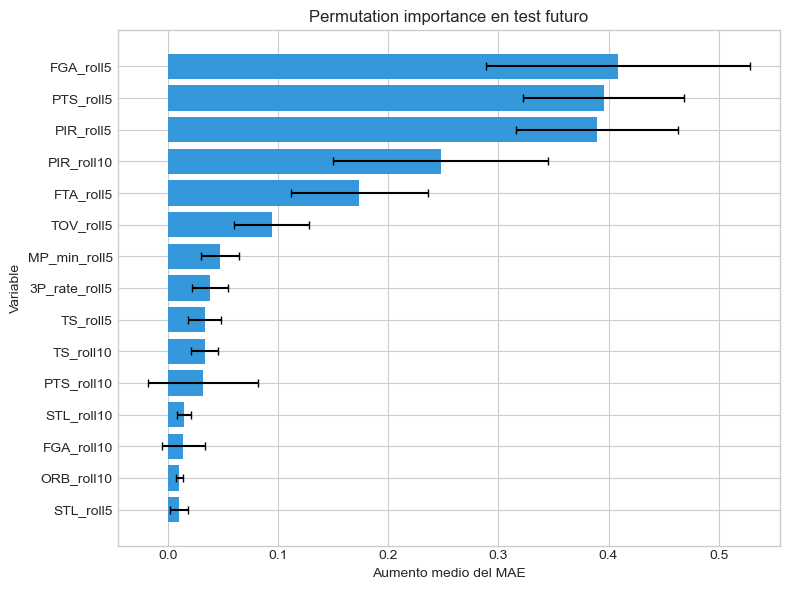

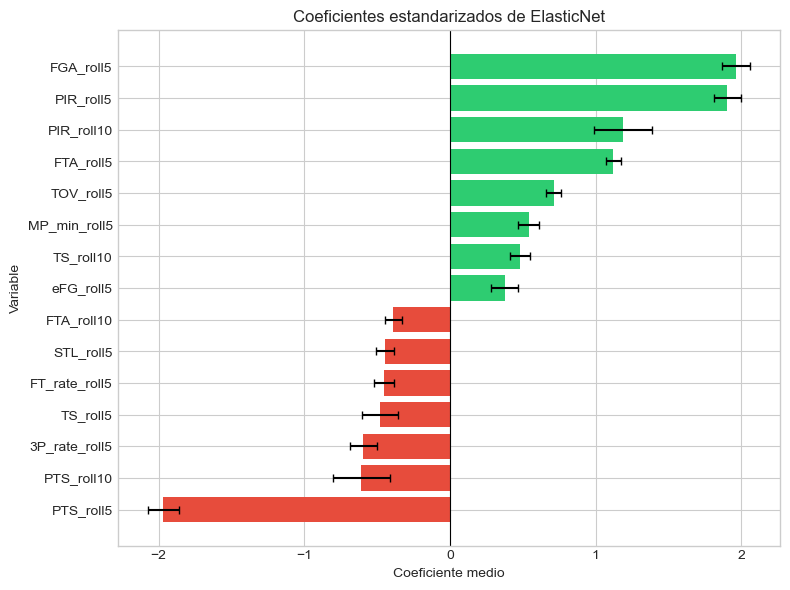

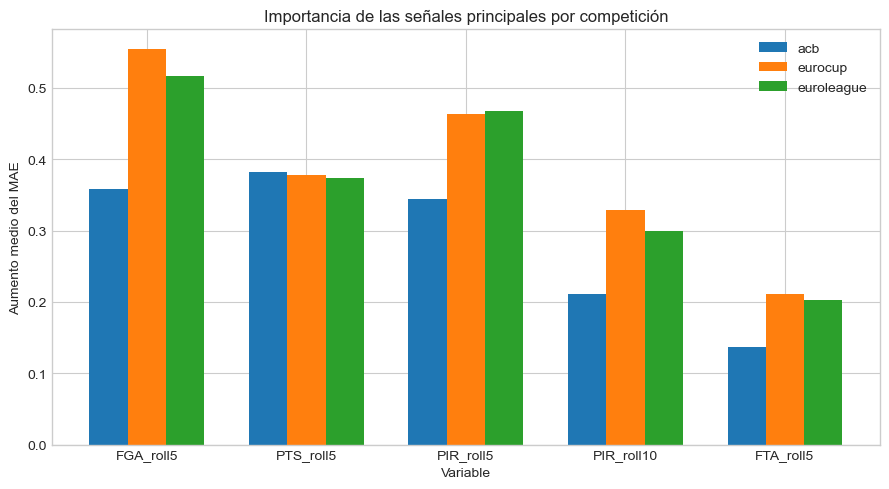

In [7]:
top_permutation = global_importance.head(15).sort_values("importance_mae_mean")
top_coefficients = coefficient_summary.query("model == 'ElasticNet' and feature_scale == 'standardized_numeric'").head(15).sort_values("coefficient_mean")
competition_plot = permutation_summary.query("competition != 'ALL' and feature in @top_features").copy()
top_permutation.to_csv(TABLE_DIR / "figure_permutation_source.csv", index=False)
top_coefficients.to_csv(TABLE_DIR / "figure_coefficients_source.csv", index=False)
competition_plot.to_csv(TABLE_DIR / "figure_competition_importance_source.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_permutation["feature"], top_permutation["importance_mae_mean"], xerr=top_permutation["importance_mae_between_fold_std"], color="#3498db", capsize=3)
ax.set(title="Permutation importance en test futuro", xlabel="Aumento medio del MAE", ylabel="Variable")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "permutation_importance.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#2ecc71" if value >= 0 else "#e74c3c" for value in top_coefficients["coefficient_mean"]]
ax.barh(top_coefficients["feature"], top_coefficients["coefficient_mean"], xerr=top_coefficients["coefficient_std"], color=colors, capsize=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Coeficientes estandarizados de ElasticNet", xlabel="Coeficiente medio", ylabel="Variable")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "elasticnet_coefficients.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
competitions = sorted(competition_plot["competition"].unique())
x = np.arange(len(top_features)); width = 0.24
for index, competition in enumerate(competitions):
    values = competition_plot.set_index(["competition", "feature"]).loc[competition].reindex(top_features)
    ax.bar(x + (index - 1) * width, values["importance_mae_mean"], width, label=competition)
ax.set(title="Importancia de las señales principales por competición", xlabel="Variable", ylabel="Aumento medio del MAE", xticks=x, xticklabels=top_features)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "permutation_by_competition.png", dpi=160, bbox_inches="tight")
plt.show()

## Conclusión y límites

El ranking regenerado identifica las señales dominantes y cuantifica su estabilidad entre folds y competiciones. El patrón debe leerse conjuntamente porque las ventanas de cinco y diez partidos y las estadísticas de volumen están correlacionadas.

Estas variables son útiles para predecir dentro del protocolo, pero no puede afirmarse que aumentar tiros, minutos o puntos cause un PIR futuro mayor ni que el ranking mida talento independiente del rol.

La permutation importance se adopta como ranking principal para la memoria y los coeficientes se utilizan para explicar dirección y estabilidad, acompañados siempre por la advertencia de colinealidad.